This notebook trains a YOLOv8n car detector, then tests how a structured visual patch affects recall.

In [1]:
!pip install kagglehub opencv-python-headless numpy matplotlib tensorflow scikit-learn

In [2]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.5 MB/s eta 0:00:00


In [3]:
import kagglehub
import os
import numpy as np
import cv2
import random as rn
import matplotlib.pyplot as plt
import yaml
from ultralytics import YOLO
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


The next step downloads the cars dataset and fine-tunes YOLOv8n using a fixed data.yaml path.

Downloading Dataset

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdallahwagih/cars-detection")

print("Path to dataset files:", path)

100%|██████████| 38.2M/38.2M [00:00<00:00, 168MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahwagih/cars-detection/versions/1


In [5]:
inner_path = os.path.join(path, 'Cars Detection')
original_yaml_path = os.path.join(inner_path, 'data.yaml')

# 2. Update the YAML to use absolute paths
with open(original_yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Point YOLO to the correct subdirectories
config['path'] = inner_path
config['train'] = 'train/images'
config['val'] = 'valid/images'
config['test'] = 'test/images'

# Save the fixed version
fixed_yaml_path = 'fixed_data.yaml'
with open(fixed_yaml_path, 'w') as f:
    yaml.dump(config, f)


# 3. Start Training
model = YOLO('yolov8n.pt')

model.train(
    data=fixed_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    name='yolov8_cars_detection'
)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=fixed_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_cars_detection, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f48906a3410>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

This section creates a dense patch, overlays it on detected cars, and compares clean versus attacked recall.

In [6]:
test_img_dir = os.path.join(path, 'Cars Detection/test/images')
test_files = [f for f in os.listdir(test_img_dir) if f.endswith(('.jpg', '.png'))][:126]
model_path = 'runs/detect/yolov8_cars_detection/weights/best.pt'
my_model = YOLO(model_path)

clean_detected_count = 0
attacked_detected_count = 0
total_images = len(test_files)

🚀 Running Strict Recall Test on 126 images...
Original Recall Rate: 74.36%
Recall drop: 25.64%


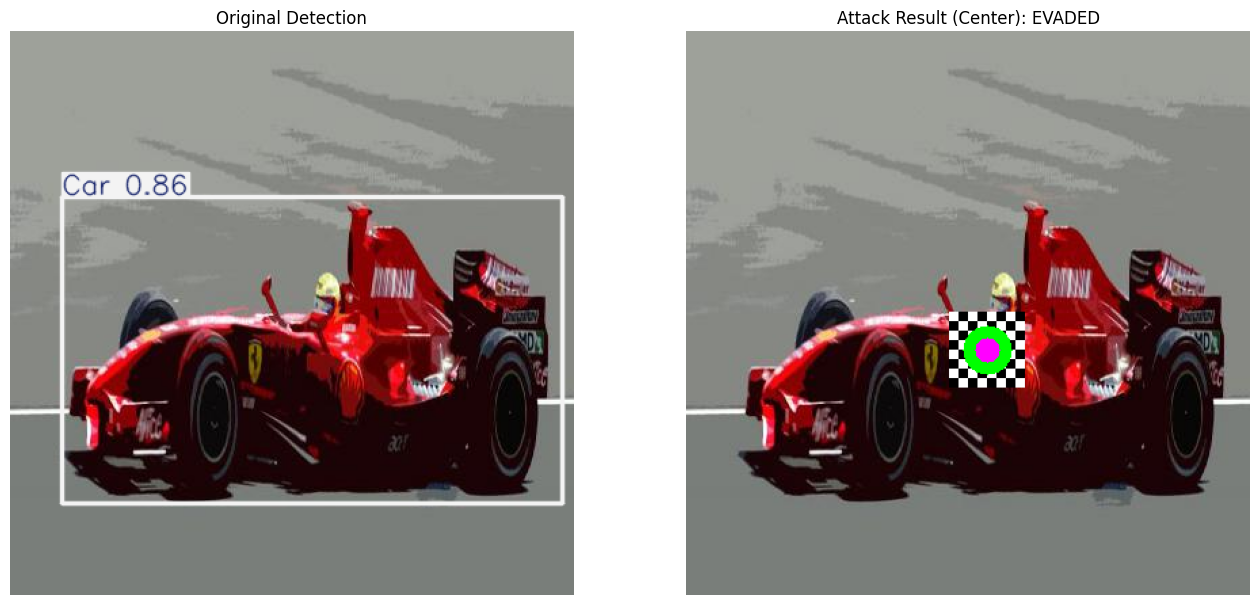

In [7]:
def generate_dense_tattoo(size):
    if size < 1: size = 1
    grid_size = 8
    cell_size = max(1, size // grid_size)
    tattoo = np.zeros((size, size, 3), dtype=np.uint8)
    for i in range(grid_size):
        for j in range(grid_size):
            color = (255, 255, 255) if (i + j) % 2 == 0 else (0, 0, 0)
            cv2.rectangle(tattoo, (j*cell_size, i*cell_size),
                          ((j+1)*cell_size, (i+1)*cell_size), color, -1)
    cv2.circle(tattoo, (size//2, size//2), size//3, (0, 255, 0), -1)
    cv2.circle(tattoo, (size//2, size//2), size//6, (255, 0, 255), -1)
    return tattoo

total_clean_cars = 0
still_detected_correctly = 0
true_evasions = 0
viz_image_clean = None
viz_image_adv = None
viz_found = False
target_viz_index = random.randint(0, len(test_files) - 1)

print(f"🚀 Running Strict Recall Test on {len(test_files)} images...")

for idx, file_name in enumerate(test_files):
    img = cv2.imread(os.path.join(test_img_dir, file_name))
    if img is None: continue
    res_clean = my_model(img, verbose=False)[0]
    car_boxes = [b for b in res_clean.boxes if int(b.cls[0]) == 2]

    if len(car_boxes) > 0:
        total_clean_cars += 1
        box = car_boxes[0]
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        w, h = x2 - x1, y2 - y1
        p_size = int(h * 0.25)
        tattoo = generate_dense_tattoo(p_size)
        img_adv = img.copy()

        py = y1 + h//2 - p_size//2
        px = x1 + w//2 - p_size//2

        y_s, y_e = max(0, py), min(img.shape[0], py + p_size)
        x_s, x_e = max(0, px), min(img.shape[1], px + p_size)
        t_y_s, t_y_e = y_s - py, p_size - (py + p_size - y_e)
        t_x_s, t_x_e = x_s - px, p_size - (px + p_size - x_e)

        if y_e > y_s and x_e > x_s:
            img_adv[y_s:y_e, x_s:x_e] = tattoo[t_y_s:t_y_e, t_x_s:t_x_e]

        res_adv = my_model(img_adv, verbose=False)[0]
        found_target_car = False
        for b_adv in res_adv.boxes:
            if int(b_adv.cls[0]) == 2:
                ax1, ay1, ax2, ay2 = map(int, b_adv.xyxy[0])
                if x1 < (ax1+ax2)//2 < x2 and y1 < (ay1+ay2)//2 < y2:
                    found_target_car = True
                    break

        if found_target_car:
            still_detected_correctly += 1
        else:
            true_evasions += 1

        if idx == target_viz_index or (viz_image_clean is None and idx == len(test_files)-1):
            viz_image_clean = res_clean.plot()
            viz_image_adv = res_adv.plot() if found_target_car else img_adv
            viz_status = "DETECTED" if found_target_car else "EVADED"
            viz_found = True

recall_val = (still_detected_correctly / total_clean_cars) * 100 if total_clean_cars > 0 else 0
evasion_val = (true_evasions / total_clean_cars) * 100 if total_clean_cars > 0 else 0

print(f"Original Recall Rate: {recall_val:.2f}%")
print(f"Recall drop: {evasion_val:.2f}%")

if viz_found:
    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.title("Original Detection")
    plt.imshow(cv2.cvtColor(viz_image_clean, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title(f"Attack Result (Center): {viz_status}")
    plt.imshow(cv2.cvtColor(viz_image_adv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

The final output reports recall drop and visualizes one clean image against its attacked version.